In [1]:
#L13 task 1 

import numpy as np
import matplotlib.pyplot as plt
#import the load_digits dataset
from sklearn.datasets import load_digits
#import isomap 
from sklearn.manifold import Isomap

digits = load_digits()


print(digits.data.shape)

# The images themselves
print(digits.images[0])

# The data for use in our algorithms
print(digits.data[0])

# The labels
print(digits.target)
print(digits.target[0])

#We'd like to visualize our points within the 64-dimensional parameter space, but it's difficult to plot points in $N=64$ dimensions! So we need to reduce the dimensionality of the space






(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]
0


In [4]:
digits, target = load_digits(return_X_y=True)#using return_X_y=True i get only x and y im umpacking 

print(digits.shape)
print(target.shape)

embedding = Isomap(n_components=48)
X_transformed = embedding.fit_transform(digits[:100])
print(X_transformed.shape)

(1797, 64)
(1797,)
(100, 48)


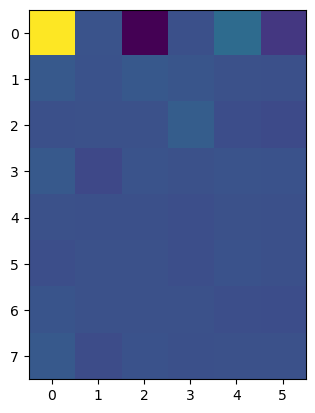

In [5]:
test = X_transformed[0]
plt.imshow(test.reshape(8,6))


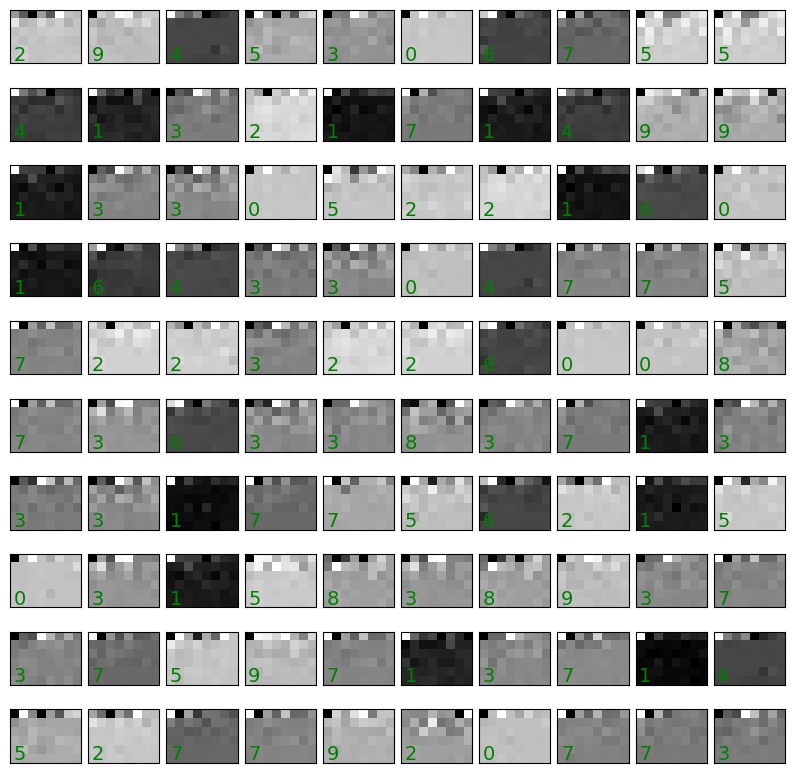

In [7]:
fig, axes = plt.subplots(10,10, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(X_transformed.shape[0],100) #vector line of 100 numbers extracted from 0 and X-1 (1797)


for i, ax in enumerate(axes.flat):
    ax.imshow((X_transformed[mychoices[i]].reshape(6,8)), 
              cmap='binary')
    ax.text(0.05, 0.05, str(target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [10]:
#part 2 Supervised Learning: Classification on Digits
#Split the dataset taking 80% of the images as tranining dataset and leaving the other 20% as a validation set

from sklearn.model_selection import train_test_split as tts

X_train , X_test, y_train, y_test = tts(digits, target, test_size = 0.2, random_state = 42 , shuffle=True, stratify=target)

In [31]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0, max_iter=10000, solver='sag' ).fit(X_train, y_train)

predict = clf.predict(X_test[:5])
accuracy = clf.score(X_test, y_test) #this done the same for accuracy_score 

print(predict, y_test[:5])
print(accuracy)



[5 2 8 8 7] [5 2 8 1 7]
0.9611111111111111


In [25]:
from sklearn.metrics import accuracy_score

#compute the accuracy on the data already studied
y_train_pred = clf.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)

#compute the accuracy on the validation set 
y_test_pred = clf.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)

print(acc_train)
print(acc_test)


1.0
0.9611111111111111


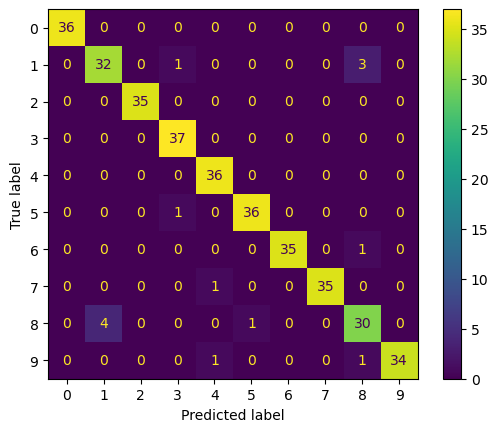

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

matrix = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
disp.plot()
plt.show()